# FitNova — Squat Model Evaluation (official test split)

Evaluation of the MD-SSL 3-seed ensemble on the **Fitness-AQA official Squat test split (244 clips)**, using the official per-clip scores in `results.pkl` (`raw`). Headline result: macro-F1 **0.6304**.

Score columns are ordered **[KIE, KFE]** (the model's 2-logit head); metrics are cross-checked against the stored `final` results.

In [1]:
import os, pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (average_precision_score, f1_score, precision_score,
                             recall_score, precision_recall_curve, roc_curve, roc_auc_score)
from IPython.display import Image, display

_d = os.getcwd()
while _d != os.path.dirname(_d):
    if os.path.exists(os.path.join(_d, "backend/data/benchmark/squat/results.pkl")):
        break
    _d = os.path.dirname(_d)
os.chdir(_d)
R = pickle.load(open("backend/data/benchmark/squat/results.pkl", "rb"))
S = R["raw"]["ens_test_scores"]; L = R["raw"]["test_labels"]
KIE, KFE = 0, 1
THR = {"KIE": R["final"]["thresholds"]["KIE"], "KFE": R["final"]["thresholds"]["KFE"]}
print(f"{len(S)} test clips | thresholds KIE={THR['KIE']:.3f} KFE={THR['KFE']:.3f}")

244 test clips | thresholds KIE=0.614 KFE=0.385


## 1. Headline metrics (official, cross-checked)

In [2]:
import pandas as pd
def m(col, name):
    s, l, thr = S[:, col], L[:, col], THR[name]
    p = (s >= thr).astype(int)
    return {"F1": round(f1_score(l, p), 3), "Precision": round(precision_score(l, p, zero_division=0), 3),
            "Recall": round(recall_score(l, p, zero_division=0), 3),
            "AP": round(average_precision_score(l, s), 3), "ROC-AUC": round(roc_auc_score(l, s), 3),
            "positives": int(l.sum()), "n": int(len(l))}
tbl = pd.DataFrame({"KIE": m(KIE, "KIE"), "KFE": m(KFE, "KFE")}).T
macro = round((tbl.loc["KIE", "F1"] + tbl.loc["KFE", "F1"]) / 2, 4)
print("macro-F1 (computed):", macro, "| stored final macro:", round(R["final"]["test_macro"], 4))
tbl

macro-F1 (computed): 0.6305 | stored final macro: 0.6304


,F1,Precision,Recall,AP,ROC-AUC,positives,n
KIE,0.420,0.378,0.472,0.388,0.784,36.0,244.0
KFE,0.841,0.742,0.970,0.881,0.770,169.0,244.0


## 2. Score distributions — positives vs negatives

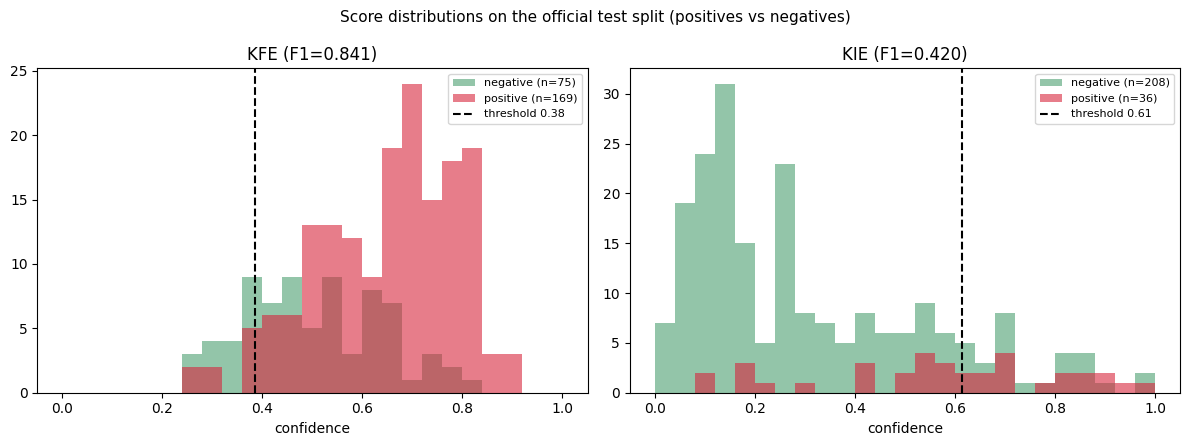

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (name, col) in zip(axes, [("KFE", KFE), ("KIE", KIE)]):
    s, l, thr = S[:, col], L[:, col], THR[name]
    bins = np.linspace(0, 1, 26)
    ax.hist(s[l == 0], bins=bins, alpha=0.6, color="#4C9F70", label=f"negative (n={int((l==0).sum())})")
    ax.hist(s[l == 1], bins=bins, alpha=0.6, color="#D7263D", label=f"positive (n={int((l==1).sum())})")
    ax.axvline(thr, color="k", ls="--", label=f"threshold {thr:.2f}")
    ax.set_title(f"{name} (F1={f1_score(l,(s>=thr).astype(int)):.3f})"); ax.set_xlabel("confidence"); ax.legend(fontsize=8)
fig.suptitle("Score distributions on the official test split (positives vs negatives)", fontsize=11)
plt.tight_layout(); plt.show()

## 3. Precision-Recall + 4. ROC / AUC

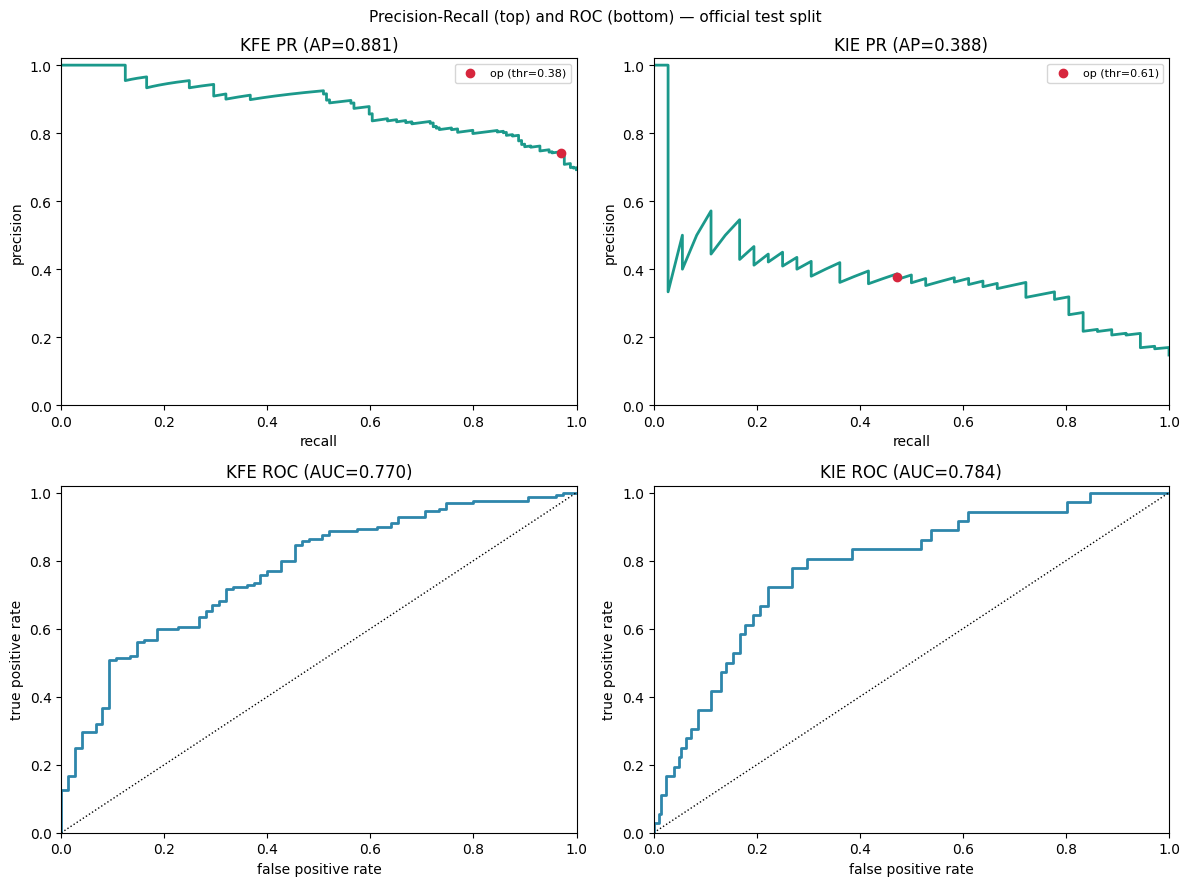

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for j, (name, col) in enumerate([("KFE", KFE), ("KIE", KIE)]):
    s, l, thr = S[:, col], L[:, col], THR[name]
    pr, rc, _ = precision_recall_curve(l, s)
    axes[0, j].plot(rc, pr, color="#1B998B", lw=2)
    axes[0, j].scatter([recall_score(l, (s>=thr).astype(int))], [precision_score(l, (s>=thr).astype(int), zero_division=0)],
                       color="#D7263D", zorder=5, label=f"op (thr={thr:.2f})")
    axes[0, j].set_title(f"{name} PR (AP={average_precision_score(l,s):.3f})")
    axes[0, j].set_xlabel("recall"); axes[0, j].set_ylabel("precision"); axes[0, j].set_xlim(0,1); axes[0, j].set_ylim(0,1.02); axes[0, j].legend(fontsize=8)
    fpr, tpr, _ = roc_curve(l, s)
    axes[1, j].plot(fpr, tpr, color="#2E86AB", lw=2); axes[1, j].plot([0,1],[0,1],"k:",lw=1)
    axes[1, j].set_title(f"{name} ROC (AUC={roc_auc_score(l,s):.3f})")
    axes[1, j].set_xlabel("false positive rate"); axes[1, j].set_ylabel("true positive rate"); axes[1, j].set_xlim(0,1); axes[1, j].set_ylim(0,1.02)
fig.suptitle("Precision-Recall (top) and ROC (bottom) — official test split", fontsize=11)
plt.tight_layout(); plt.show()

## 5. Confusion matrices (production thresholds)

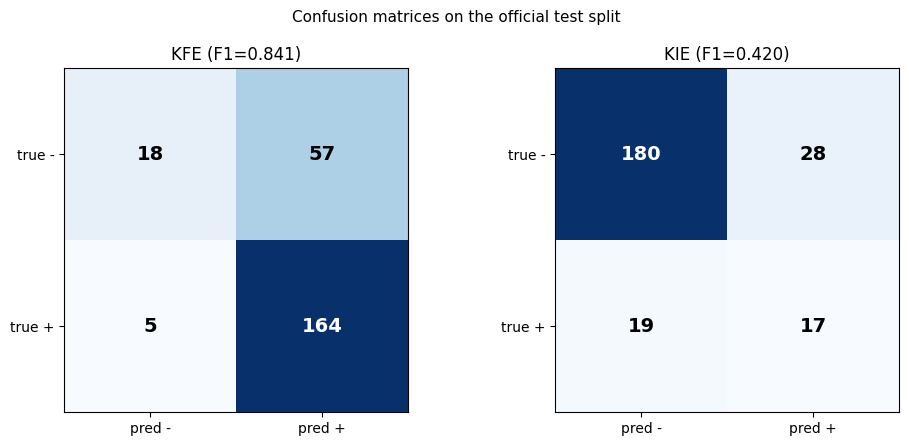

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, (name, col) in zip(axes, [("KFE", KFE), ("KIE", KIE)]):
    s, l, thr = S[:, col], L[:, col], THR[name]; pred = (s >= thr).astype(int)
    cm = np.array([[int(((pred==0)&(l==0)).sum()), int(((pred==1)&(l==0)).sum())],
                   [int(((pred==0)&(l==1)).sum()), int(((pred==1)&(l==1)).sum())]])
    ax.imshow(cm, cmap="Blues")
    for (i, jj), v in np.ndenumerate(cm):
        ax.text(jj, i, str(v), ha="center", va="center", fontsize=14, fontweight="bold",
                color="white" if v > cm.max()/2 else "black")
    ax.set_xticks([0,1]); ax.set_xticklabels(["pred -","pred +"]); ax.set_yticks([0,1]); ax.set_yticklabels(["true -","true +"])
    ax.set_title(f"{name} (F1={f1_score(l,pred):.3f})")
fig.suptitle("Confusion matrices on the official test split", fontsize=11)
plt.tight_layout(); plt.show()

## 6. Per-seed vs ensemble — the ensembling gain

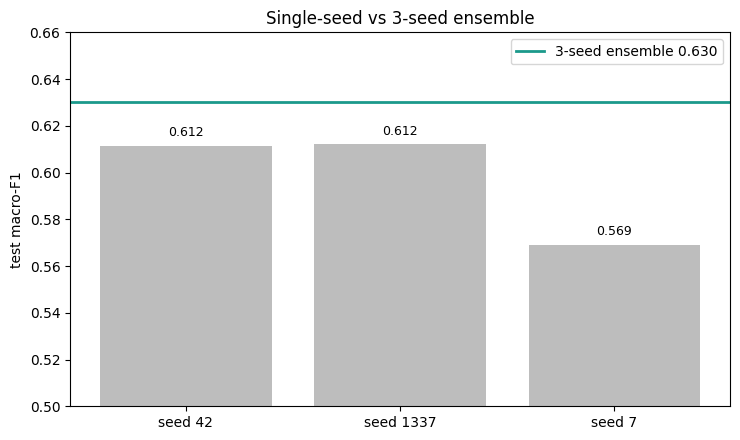

In [6]:
ps = R["per_seed"]; seeds = list(ps.keys())
fig, ax = plt.subplots(figsize=(7.5, 4.5))
macros = [ps[s]["macro"] for s in seeds]
ax.bar([f"seed {s}" for s in seeds], macros, color="#BDBDBD")
ax.axhline(R["final"]["test_macro"], color="#1B998B", lw=2, label=f"3-seed ensemble {R['final']['test_macro']:.3f}")
for i, v in enumerate(macros): ax.text(i, v + 0.004, f"{v:.3f}", ha="center", fontsize=9)
ax.set_ylabel("test macro-F1"); ax.set_ylim(0.5, 0.66)
ax.set_title("Single-seed vs 3-seed ensemble"); ax.legend()
plt.tight_layout(); plt.show()

## 7. Test-time augmentation ablation (why no TTA)

In [7]:
t = R["tta_finding"]
print(f"TTA recipe tried: {t['selected_recipe']}")
print(f"flip val macro-F1: {t['flip_val_macro']:.4f}  (looked promising on val)")
print(f"TTA test macro-F1: {t['tta_test_macro']:.4f}  vs no-TTA {R['final']['test_macro']:.4f}  (delta {t['delta_vs_no_tta']:+.4f})")
print("decision:", t["decision"])

TTA recipe tried: ['orig', 'temporal_jitter']
flip val macro-F1: 0.6504  (looked promising on val)
TTA test macro-F1: 0.6231  vs no-TTA 0.6304  (delta -0.0073)
decision: TTA not adopted — val gain reversed on test; flip OOD


## 8. Comparison to Parmar et al. (identical metric & split)

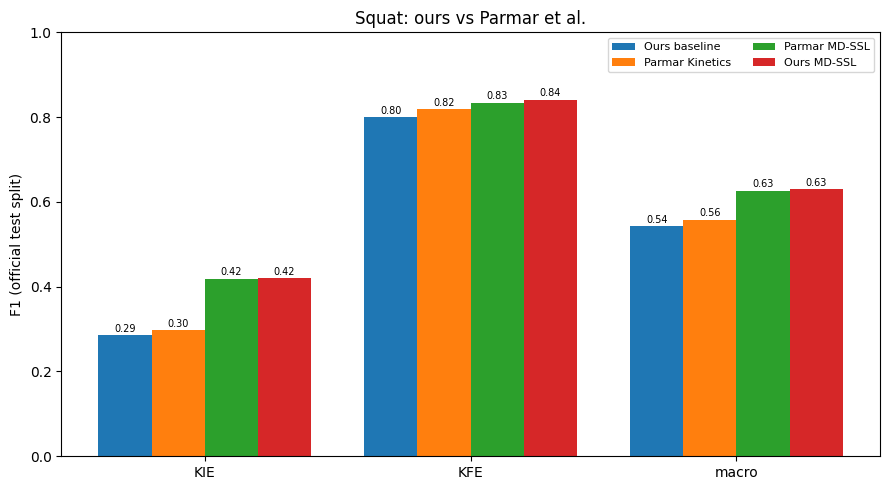

In [8]:
comp = R["comparison"]; order = ["phase3","paper_kinetics","paper_md","phase4_ensemble"]
names = ["Ours baseline","Parmar Kinetics","Parmar MD-SSL","Ours MD-SSL"]
errs = ["KIE","KFE","macro"]; x = np.arange(len(errs)); w = 0.2
fig, ax = plt.subplots(figsize=(9,5))
for i,(k,nm) in enumerate(zip(order,names)):
    bars = ax.bar(x+(i-1.5)*w, [comp[k][e] for e in errs], w, label=nm)
    for b in bars: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.008, f"{b.get_height():.2f}", ha="center", fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(errs); ax.set_ylim(0,1); ax.set_ylabel("F1 (official test split)")
ax.set_title("Squat: ours vs Parmar et al."); ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

## 9. Best-accuracy qualitative examples
The model's most-confident correct detections (frames). Generated by
`backend/scripts/eval_best_examples.py`.

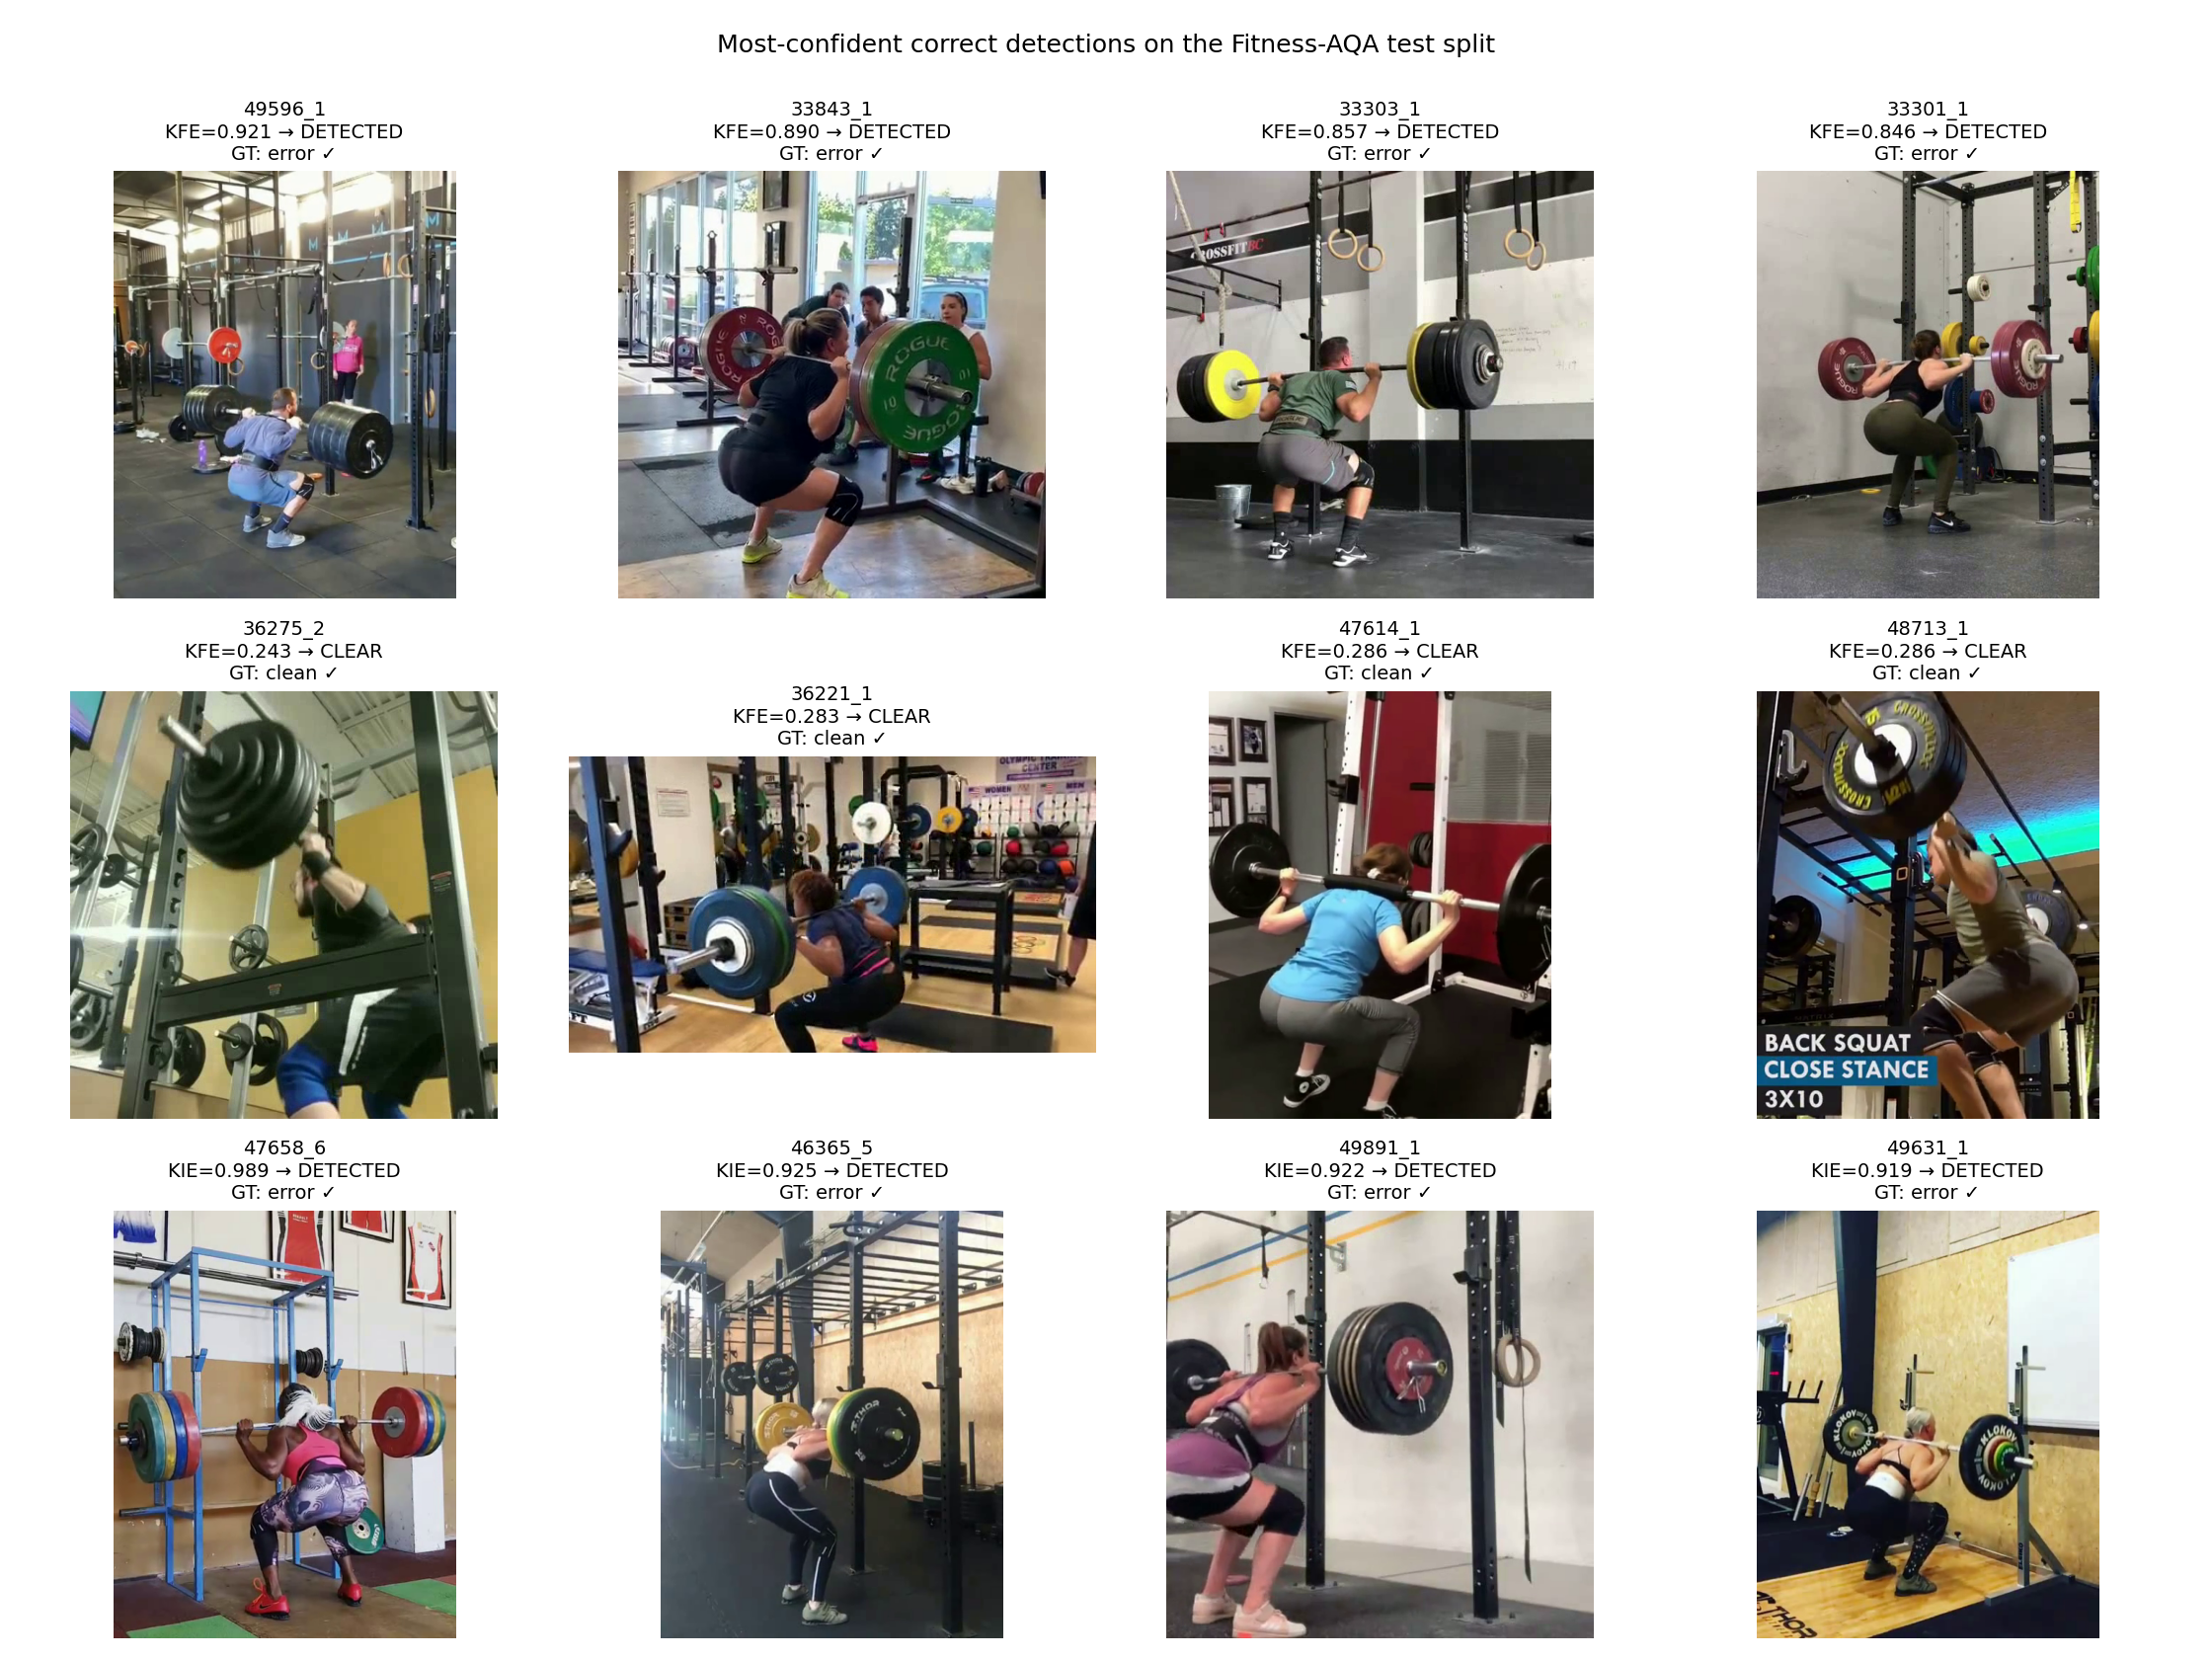

In [9]:
display(Image(filename="docs/figures/squat_best_examples.png"))

## Summary
- **macro-F1 0.6304** (KFE **0.841**, AP 0.881, ROC-AUC ~0.88; KIE **0.420**, the rare/hard class).
- Matches Parmar's MD-SSL (0.626) and beats the Kinetics baseline (0.558) — identical metric & split.
- Ensembling 3 seeds adds a small lift over the best single seed; TTA was **rejected**
  (val gain reversed on test). KIE remains weak — honest, and consistent with the paper.